# Train and evaluate XGBoost model (nested CV)

Use flattened data generated by `run/run_ml_prep.py`, where `run` is a string which indicates which round of processing was using (cuts/flattening technique), and hyperparameters found via the `optimise.ipynb` notebook.

**Flow:**
1. Assemble full dataset with outer fold indices
2. For each outer fold: train with fixed HP, find threshold, evaluate on held-out test
3. Report CV-averaged metrics with uncertainties
4. Train final model on all data with mean threshold, export to UBJ

In [1]:
version = "1.0.0"

In [2]:
import sys
sys.path.append("../../../src/ml")

In [3]:
!pwd

/home/sgrant/mu2e-cosmic/notebooks/ml/xgboost


## Assemble dataset

run = "k" 

- 2026 MLPreprocess cuts with coinc start/end time
- All coincidences and all combinations of dt, each row is a coincidence
- Events with no coincidence have NaN CRV parameters 
- No start/end time cuts
- Duration as a feature

In [4]:
run = "k"
from assemble import AssembleDataset
asm = AssembleDataset(run=run)
data = asm.assemble_dataset(n_outer_folds=5)

# data["X"] = data["X"].drop(columns=["sector"])

[LoadML] [OK] Initialised
[Load] [OK] Initialised with out_path=/home/sgrant/mu2e-cosmic/output/ml/k/data/CRY_onspill-LH_aw
[Load] [OK] Successfully loaded results from /home/sgrant/mu2e-cosmic/output/ml/k/data/CRY_onspill-LH_aw/results.pkl
[Load] [OK] Initialised with out_path=/home/sgrant/mu2e-cosmic/output/ml/k/data/CE_mix2BB_onspill-LH_aw
[Load] [OK] Successfully loaded results from /home/sgrant/mu2e-cosmic/output/ml/k/data/CE_mix2BB_onspill-LH_aw/results.pkl
[LoadML] [OK] Got full results
[Assemble] [OK] Loaded data
[Assemble] [OK] Initialised
[Assemble] [OK] Prepared 5-fold nested CV (event-level grouping)
  Total: 2163528 coincidences
  Fold test sizes: [432706, 432706, 432706, 432705, 432705]


In [5]:
asm.check_dT_window_results()

,Metric,CRY,CE Mix
0,Total,20087,578368
1,Unvetoed,10,417011
2,Fraction [%],99.95,27.90


[Load] [OK] Initialised with out_path=test_out
[pyprint] [INFO] Initialised Print with verbose = False and precision = 1
[Plot] [INFO] Initialised
[Plot] [OK] 	Wrote /home/sgrant/mu2e-cosmic/output/images/ml/k/process/h1o_3x3_cuts_CRY.png


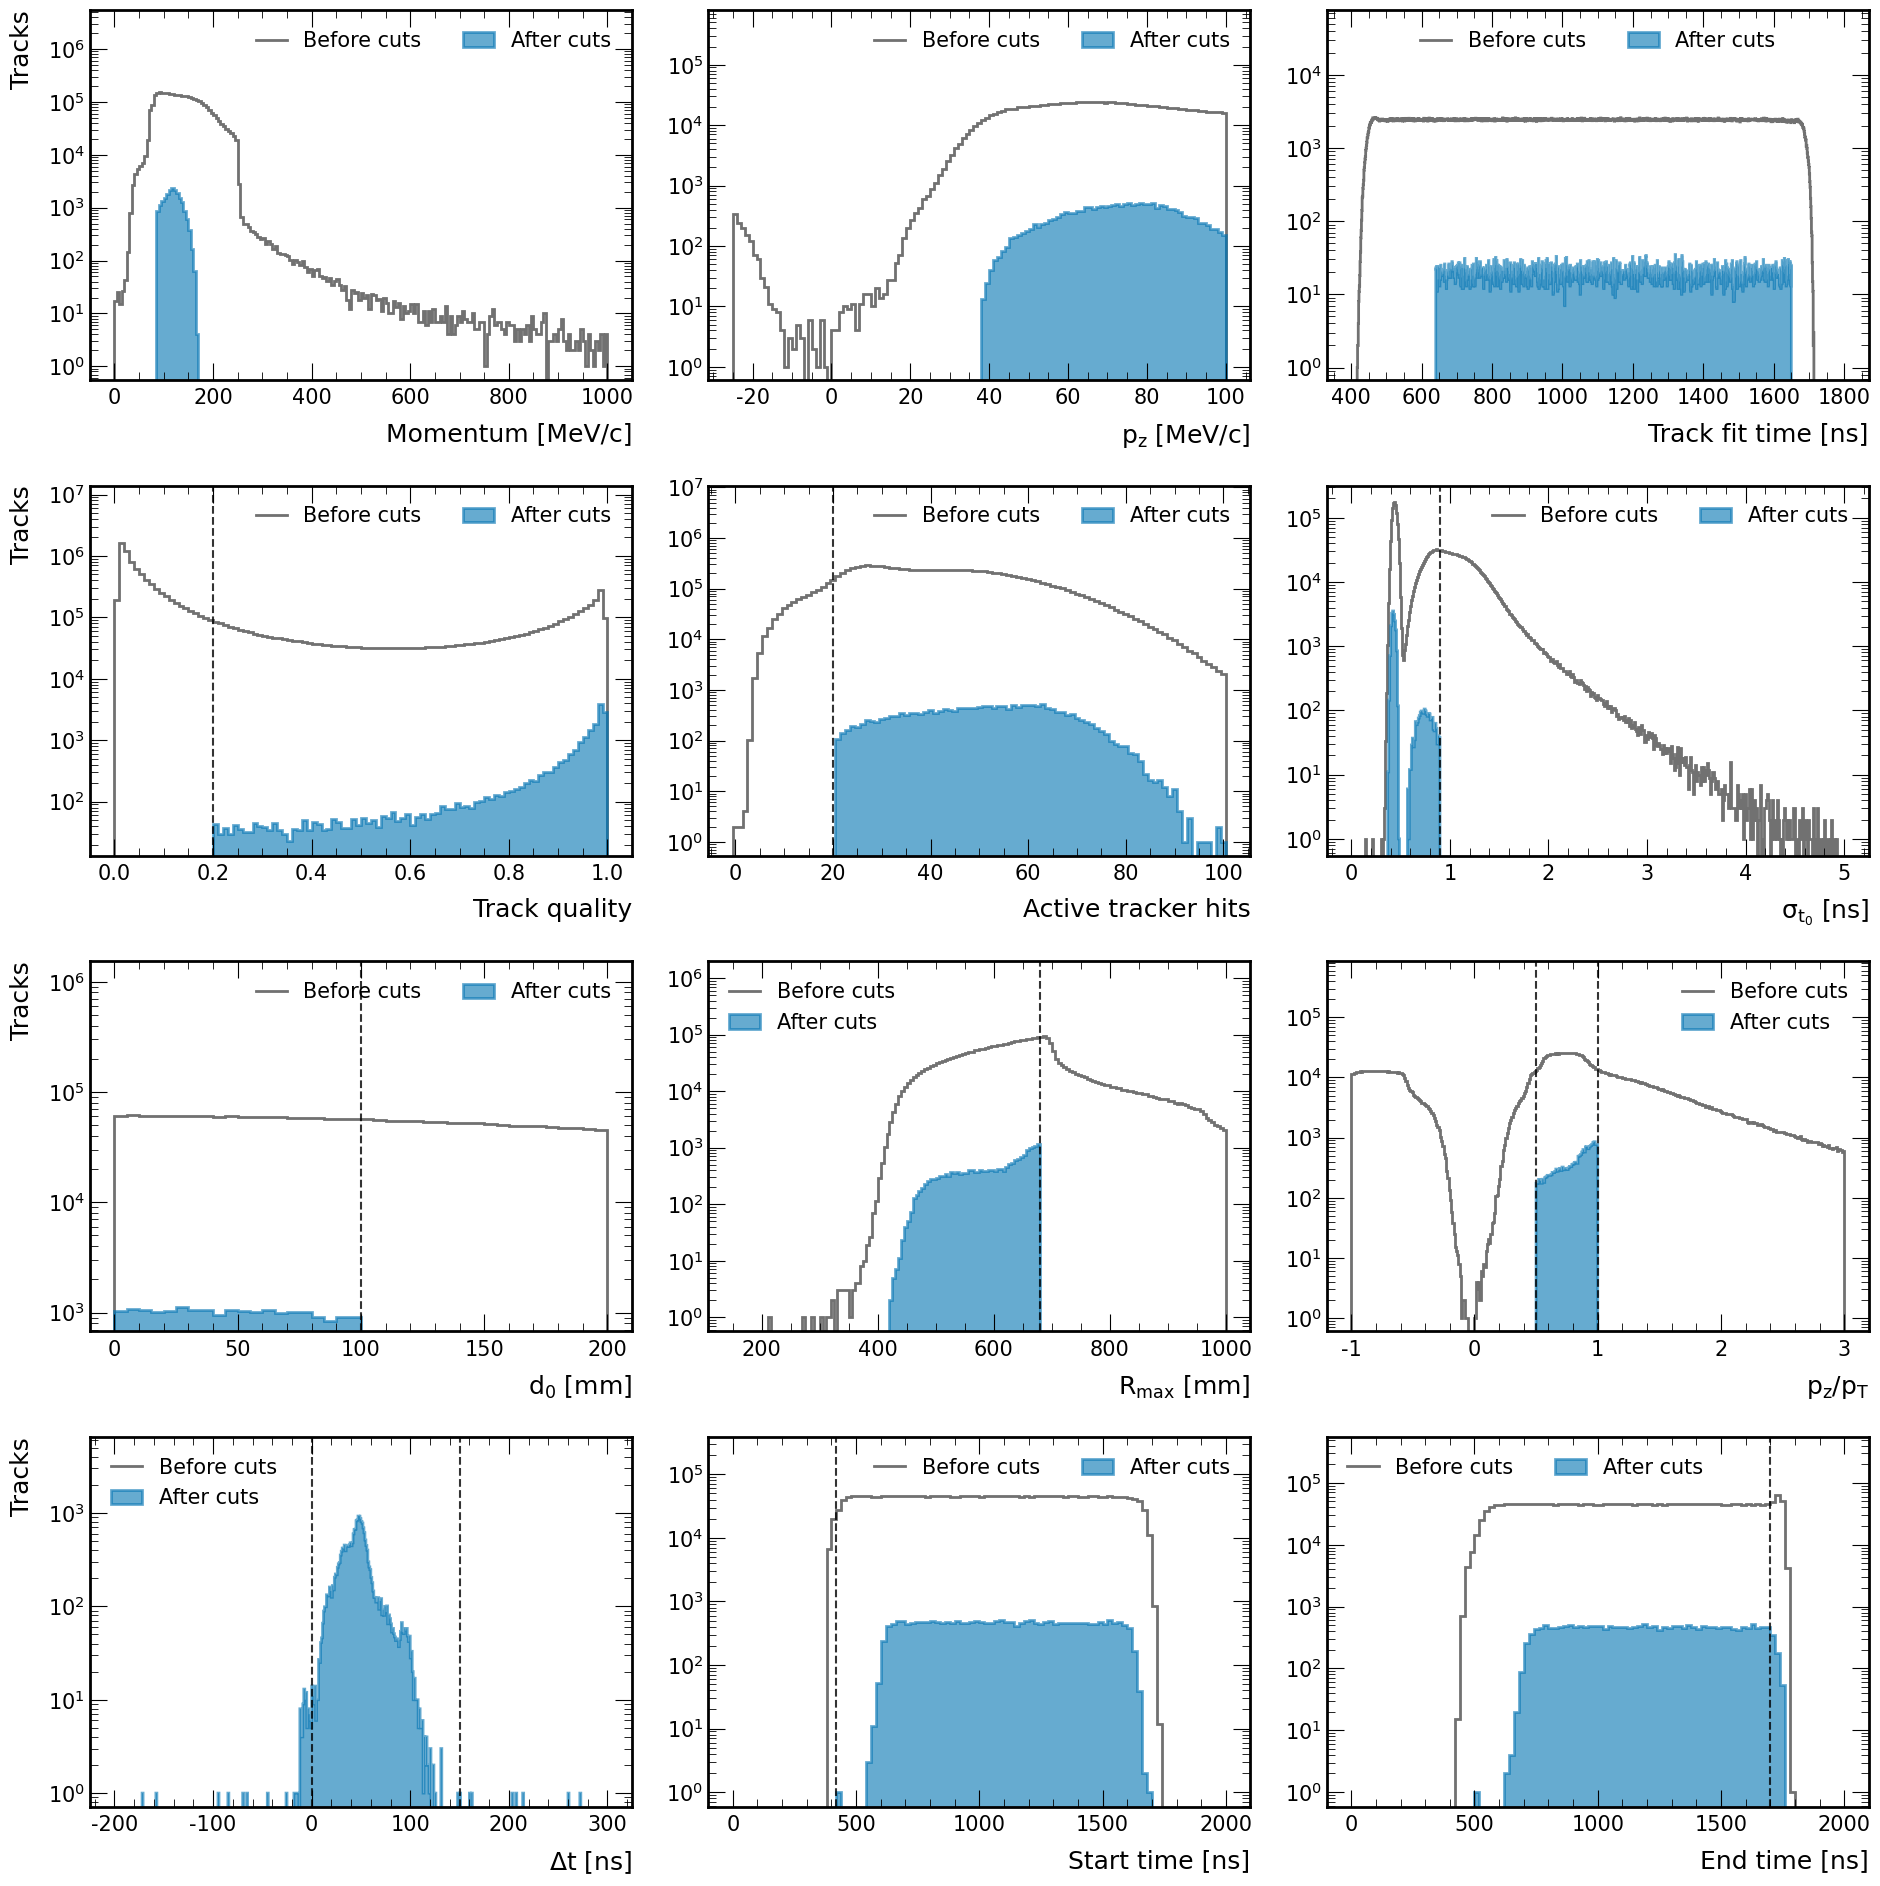

[Plot] [OK] 	Wrote /home/sgrant/mu2e-cosmic/output/images/ml/k/process/h1o_3x3_cuts_CE_mix.png


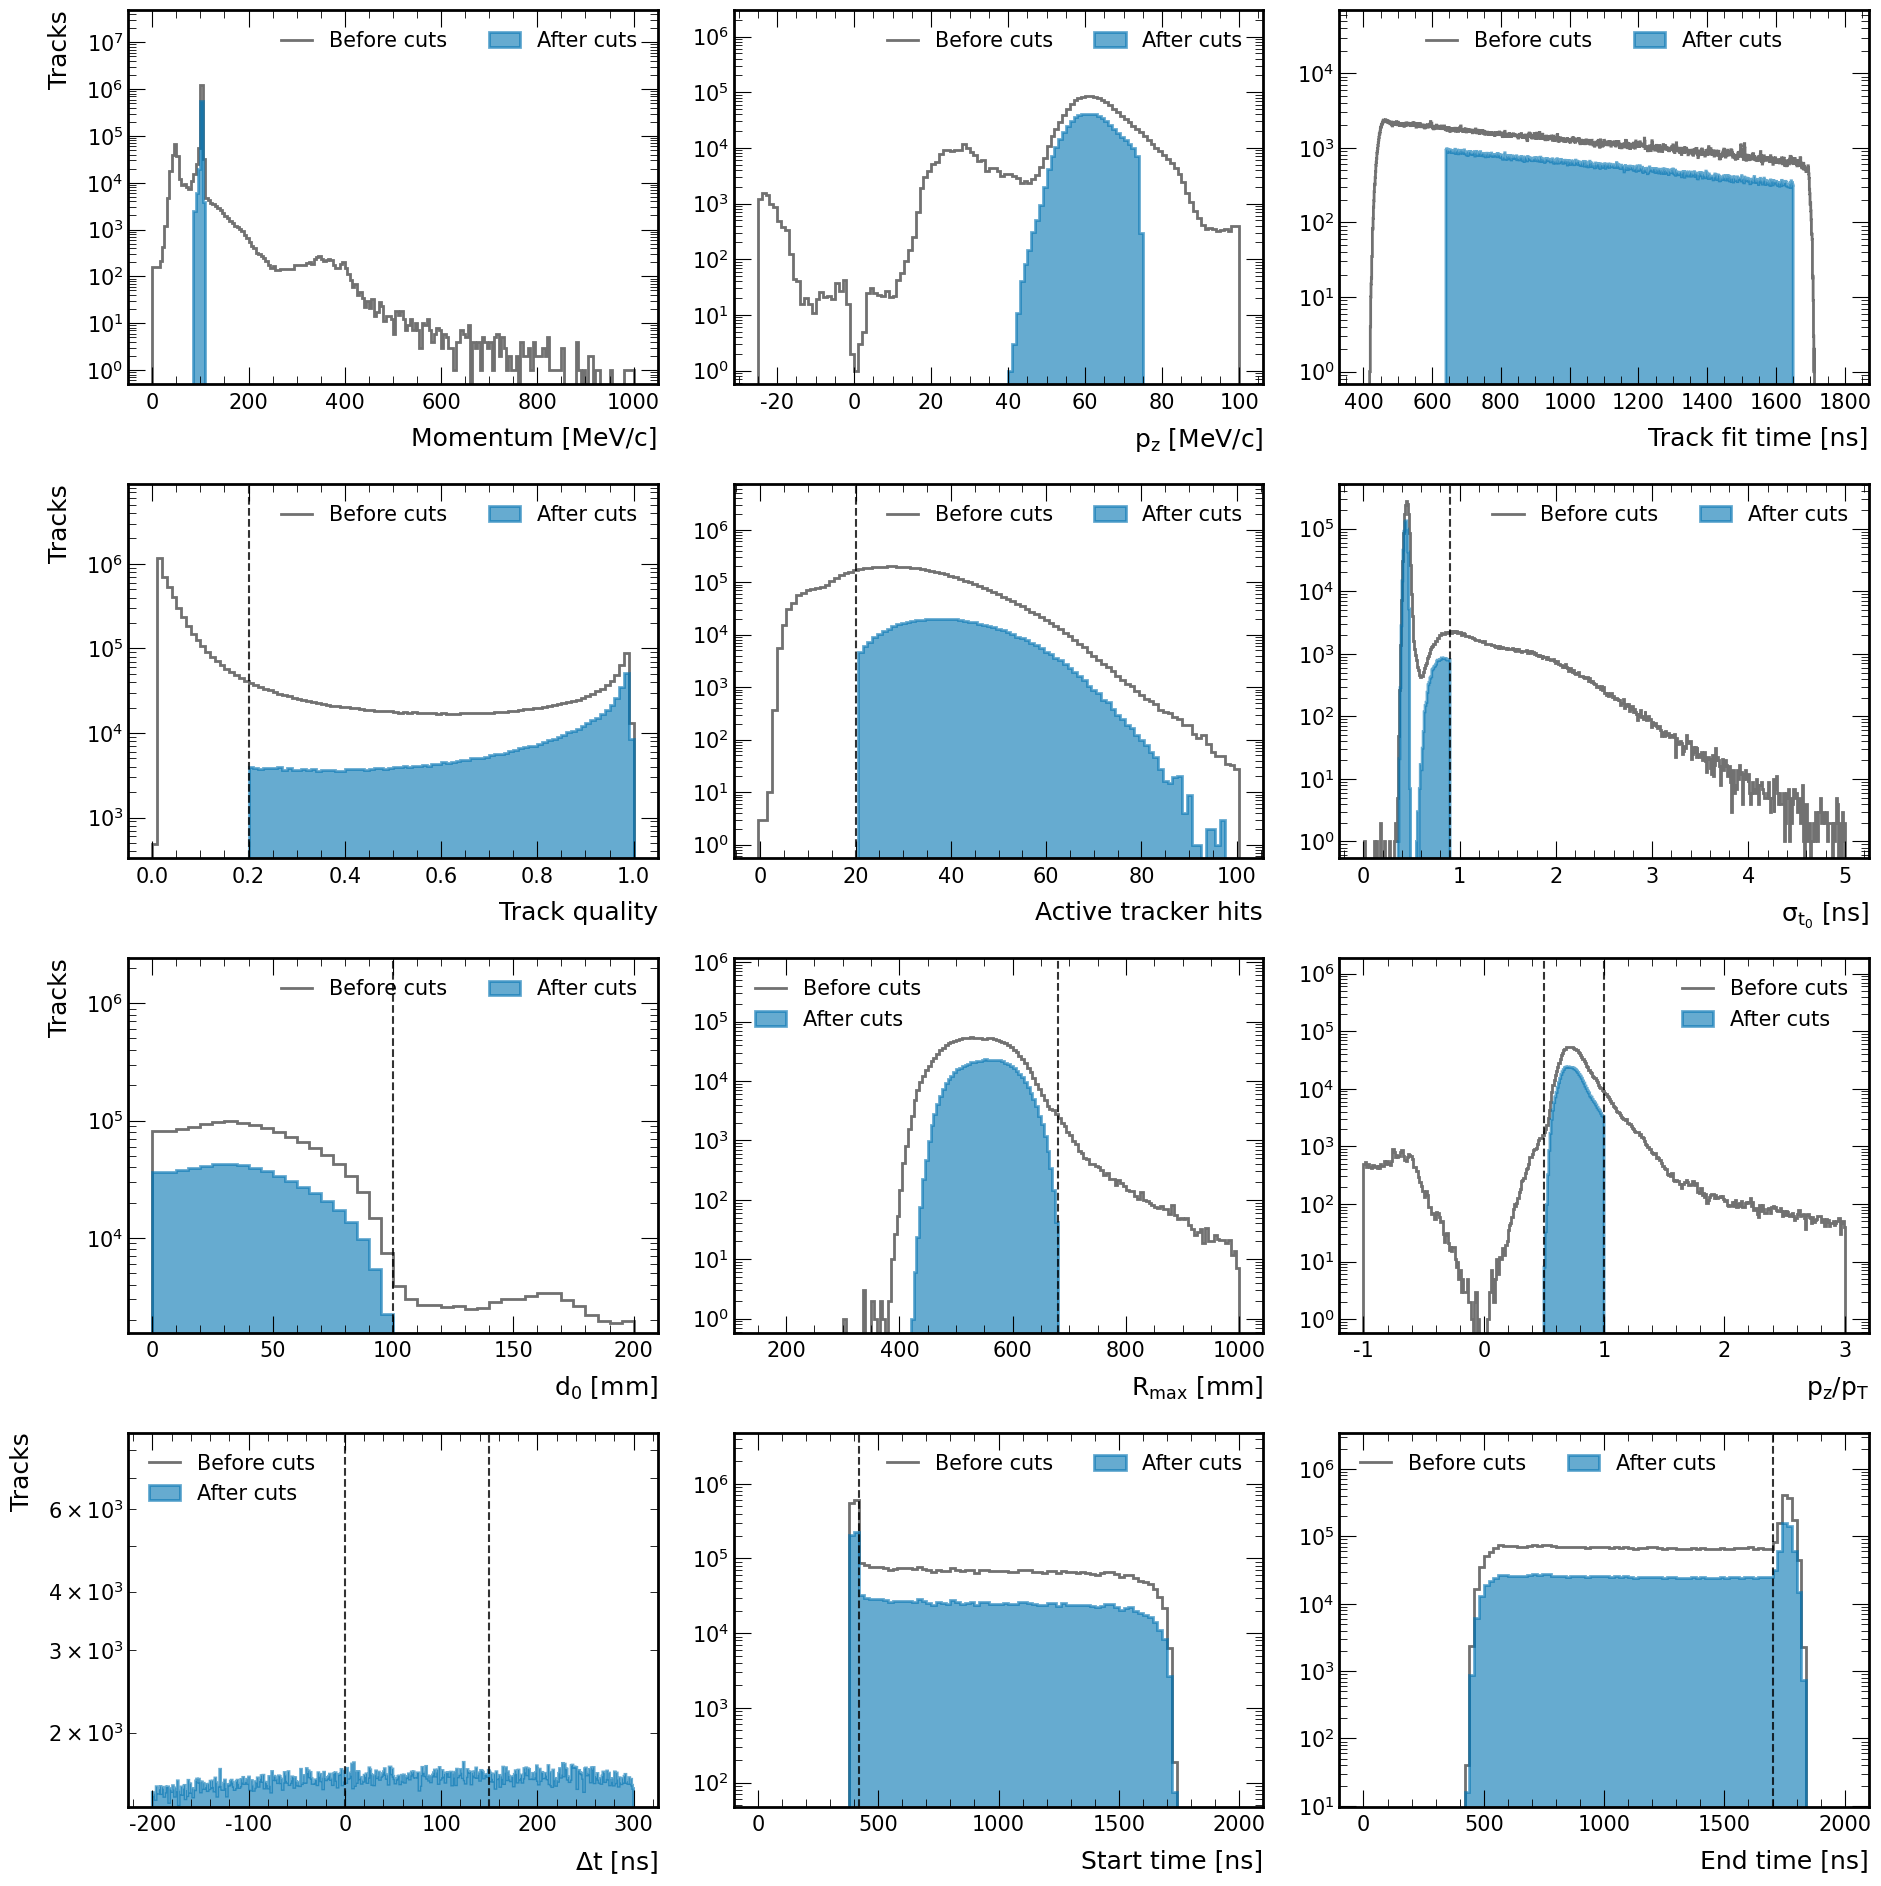

In [6]:
asm.draw_cuts()

[Assemble] [OK] Saved feature distributions to /home/sgrant/mu2e-cosmic/output/images/ml/k/process/h1o_2x4_crv_features.png


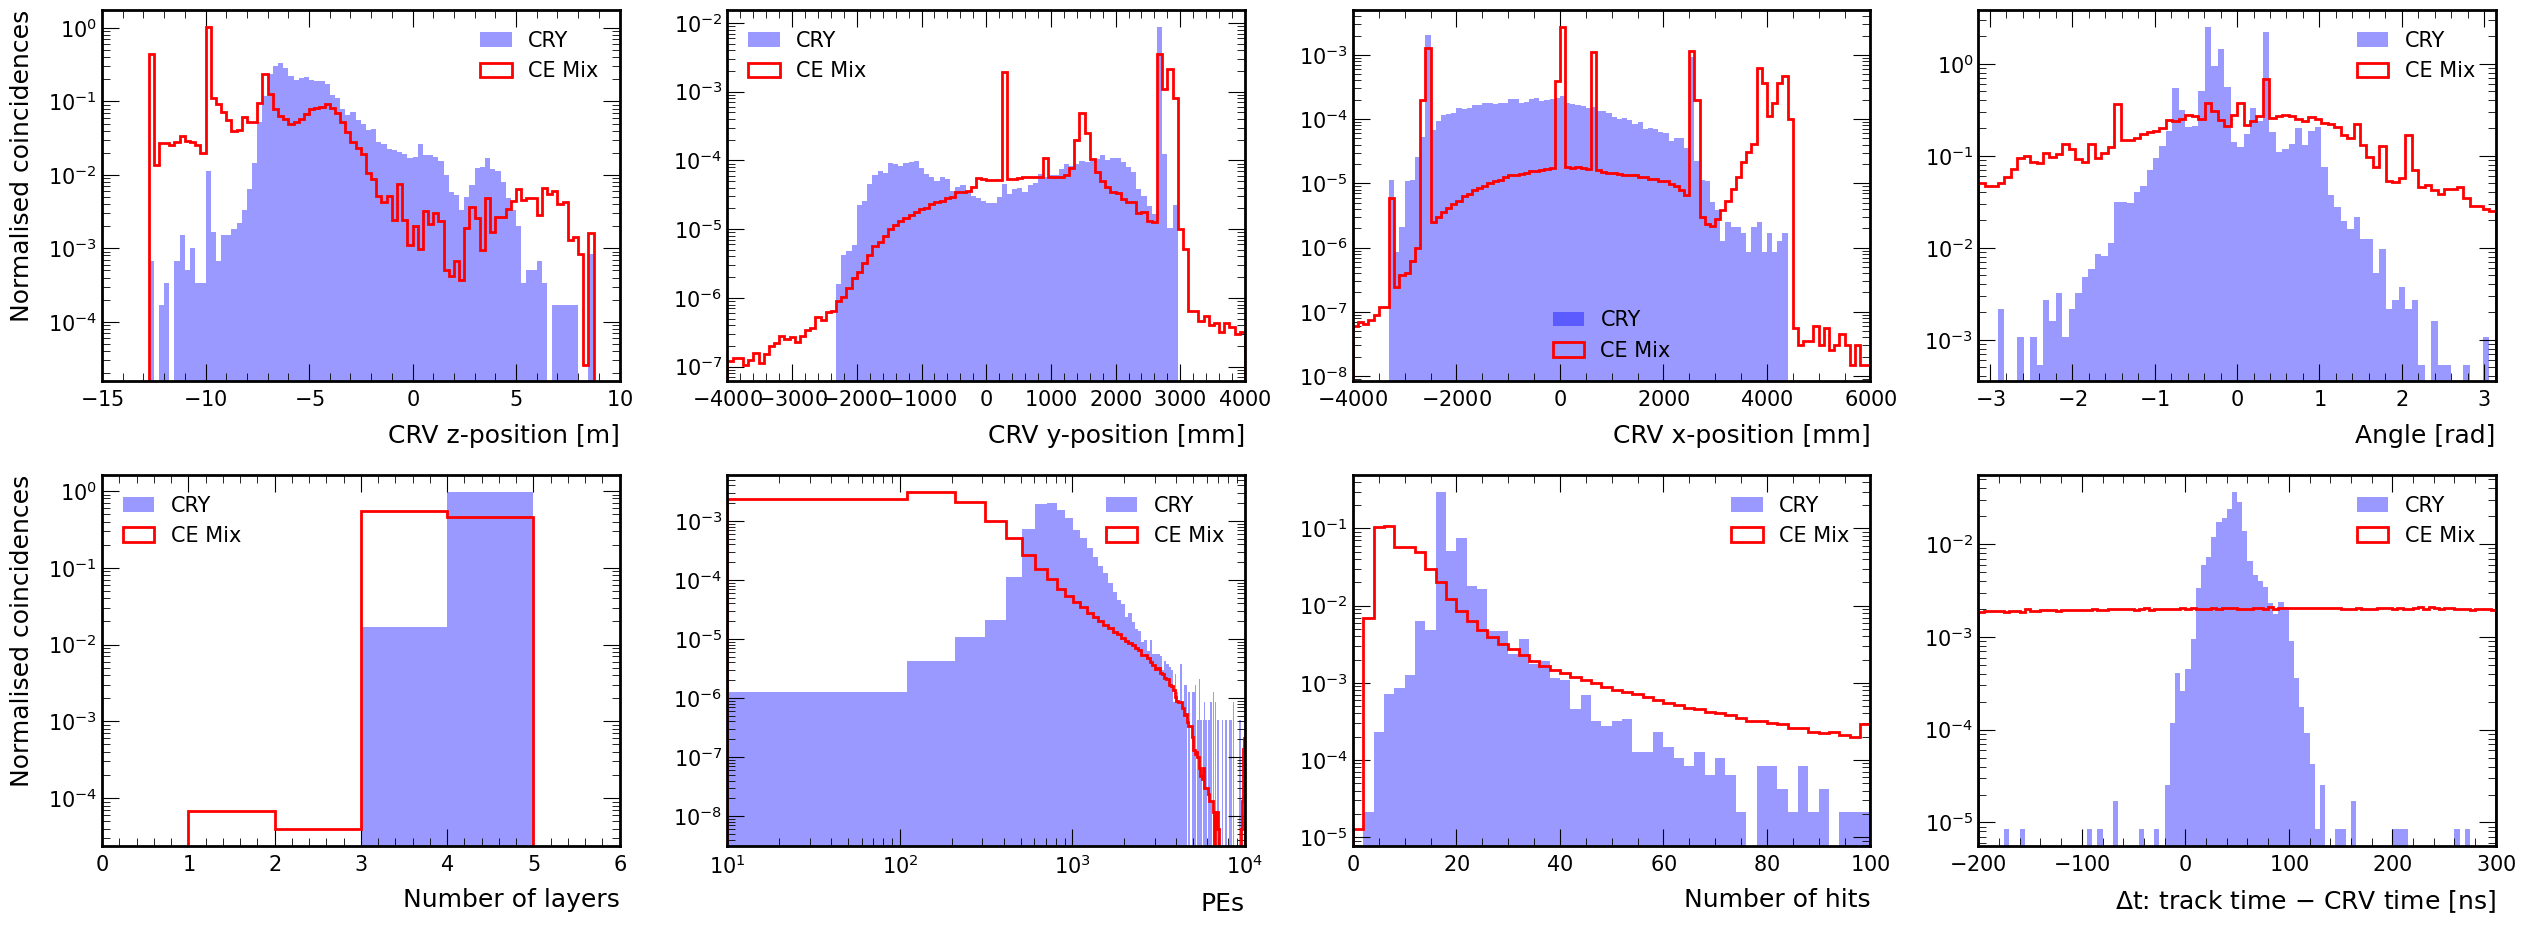

In [7]:
asm.draw_features()

In [8]:
data["df_full"]

,event,subrun,crv_x,crv_y,crv_z,PEs,dT,nHits,nLayers,angle,timeStart,timeEnd,sector,PEs_per_hit,t0,d0,tanDip,maxr,mom_mag,label
0,2650.0,98.0,-4.547474e-13,2684.661133,-7921.097656,90.724777,527.722271,4.0,3.0,0.727466,525.451538,587.951538,3.0,22.681194,1016.454419,42.117722,0.583941,617.263550,103.368034,0
1,1859.0,843.0,4.071482e+03,2862.049561,-9957.799805,285.257233,-805.731684,10.0,4.0,1.353849,1607.101807,1782.101807,4.0,28.525723,786.035162,32.673702,0.605967,602.773804,103.583145,0
2,2192.0,457.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1096.057591,8.055742,0.715509,539.576172,104.595360,0
3,556.0,411.0,6.362000e+02,1513.145508,-12567.080078,34580.207031,-397.368187,1899.0,4.0,-1.526525,412.966553,1787.966553,5.0,18.209693,661.050758,24.049637,0.879215,526.783875,104.189644,0
4,2974.0,707.0,0.000000e+00,2731.275635,-12267.968750,240.338318,-22.465829,8.0,4.0,-3.002133,983.740662,1146.240723,3.0,30.042290,1019.720328,65.952957,0.743986,470.854187,104.093399,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2163523,3061.0,925.0,3.952777e+01,2711.051514,-7511.345703,131.810699,782.745075,12.0,3.0,-1.497381,742.005493,842.005493,3.0,10.984225,1500.949542,74.319374,0.665570,633.117065,104.378433,0
2163524,3076.0,722.0,0.000000e+00,2681.962402,-2549.654053,86.194878,-311.175052,5.0,3.0,3.386727,1285.348145,1447.848145,3.0,17.238976,983.938596,30.310881,0.856973,541.797424,104.623466,0
2163525,2061.0,331.0,0.000000e+00,2701.172852,-11403.797852,260.580322,678.858792,11.0,4.0,-0.721829,716.635193,891.635193,3.0,23.689120,1384.573697,65.948845,0.930326,555.570496,104.027061,0
2163526,2004.0,40.0,-2.573767e+03,-934.724060,-4733.690430,200.804611,-146.186658,12.0,3.0,-1.477709,1139.843506,1252.343506,1.0,16.733718,976.955921,28.302200,0.711944,516.766479,103.907005,0


In [9]:
# import numpy as np
# df_full = data["df_full"]
# dur = df_full["timeEnd"] - df_full["timeStart"]
# print(dur.describe())
# print(f"inf count: {np.isinf(dur).sum()}")
# print(f"nan count: {dur.isna().sum()}")

import numpy as np
for col in data["X"].columns:
    n_inf = np.isinf(data["X"][col]).sum()
    n_nan = data["X"][col].isna().sum()
    if n_inf > 0 or n_nan > 0:
        print(f"{col}: inf={n_inf}, nan={n_nan}")

# import numpy as np
# for col in data["X_train"].columns:
#     mx = data["X_train"][col].abs().max()
#     if mx > 1e300 or np.isinf(mx):
#         print(f"{col}: max abs = {mx}"


crv_x: inf=0, nan=149937
crv_y: inf=0, nan=149937
crv_z: inf=0, nan=149937
PEs: inf=0, nan=149937
dT: inf=0, nan=149937
nHits: inf=0, nan=149937
nLayers: inf=0, nan=149937
angle: inf=0, nan=150001
sector: inf=0, nan=149937


## Train and evaluate (nested CV)

- Use hyperparameters found via grid search optimisation in optimise.ipynb
- 5-fold nested CV: outer folds for evaluation, inner folds used during optimisation
- Threshold found per outer fold, reported as mean ± std

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve
from train import Train
from validate import Validate

best_hp = {
    "n_estimators": 1000,
    "max_depth": 3,
    "learning_rate": 0.1,
}

fold_metrics = []
fold_scans = []
fold_rocs = []
fold_scores = []
fold_raws = []

for k, (train_idx, test_idx) in enumerate(data["outer_folds"]):
    fold_data = AssembleDataset.get_fold_data(data, train_idx, test_idx)

    trn = Train(fold_data, run=run, verbosity=0)
    results = trn.train(tag=f"nested_fold_{k}", save_output=False, **best_hp)

    val = Validate(results, run=run, verbosity=0)
    val.roc_auc()
    thr = val.find_threshold(min_eff=0.999, plot=False, show=False)
    fold_scans.append(thr)

    # ROC curve data
    fpr, tpr, _ = roc_curve(val.y_test, val.y_proba)
    fold_rocs.append({"fpr": fpr, "tpr": tpr, "auc": val._test_auc})

    # Event-level score distribution
    df_scores = fold_data["metadata_test"][["subrun", "event"]].copy()
    df_scores["label"] = np.asarray(fold_data["y_test"])
    df_scores["proba"] = np.asarray(val.y_proba)
    event_df = df_scores.groupby(["subrun", "event"]).agg(
        max_proba=("proba", "max"), label=("label", "first")
    )
    fold_scores.append({
        "signal": event_df.loc[event_df["label"] == 1, "max_proba"].values,
        "background": event_df.loc[event_df["label"] == 0, "max_proba"].values,
    })

    money = val.money_table(
        X=fold_data["X_test"],
        y=fold_data["y_test"],
        metadata=fold_data["metadata_test"],
        threshold=thr["threshold"],
        save_csv=False,
    )
    fold_raws.append(money["raw"])

    fold_metrics.append({
        "fold": k,
        "train_auc": val._train_auc,
        "test_auc": val._test_auc,
        "threshold": thr["threshold"],
        "veto_efficiency": thr["veto_efficiency"],
        "deadtime": thr["deadtime"],
        "veto_purity": money["raw"]["veto_purity"],
        "accuracy": money["raw"]["accuracy"],
        "f1": money["raw"]["f1"],
        "figure_of_merit": money["raw"]["figure_of_merit"],
    })
    print(f"Fold {k}: test AUC={val._test_auc:.6f}, "
          f"threshold={thr['threshold']:.4f}, "
          f"deadtime={thr['deadtime']*100:.3f}%")

import pandas as pd
metrics_df = pd.DataFrame(fold_metrics)
display(metrics_df)

In [ ]:
# CV threshold overlay plot
cv_threshold = metrics_df["threshold"].mean()
val_plotter = Validate(results, run=run, verbosity=1)
val_plotter.plot_threshold_cv(fold_scans, cv_threshold, min_eff=0.999, 
                              show=True)

In [ ]:
# ROC curves — 5 folds + mean with uncertainty band
val_plotter.plot_roc_cv(fold_rocs, show=True)

In [ ]:
# Score distribution — 5 folds overlaid with threshold
val_plotter.plot_score_distribution_cv(fold_scores, cv_threshold, show=True)

## CV summary

In [ ]:
# CV money table — ML model vs dT cut baseline
cv_threshold = metrics_df["threshold"].mean()
val_table = Validate(results, run=run, verbosity=1)
df_money = val_table.cv_money_table(fold_raws)
display(df_money)

## Final model

Train on all data with fixed hyperparameters and CV-averaged threshold. Export to UBJ.

In [13]:
!pwd

/home/sgrant/mu2e-cosmic/notebooks/ml/xgboost


In [15]:
from pathlib import Path

# Train on full dataset
full_data = AssembleDataset.get_full_train_data(data)
trn = Train(full_data, run=run)
results = trn.train(tag="final", save_output=True, **best_hp)

# CV-averaged threshold
cv_threshold = metrics_df["threshold"].mean()
cv_threshold_std = metrics_df["threshold"].std()
print(f"CV threshold: {cv_threshold:.4f} ± {cv_threshold_std:.4f}")

# Export UBJ
out_dir = Path(f"../../../output/ml/{run}/results/final")
# out_dir.mkdir(parents=True, exist_ok=True)
model_name = f"model_{version}.ubj"
results["model"].get_booster().save_model(str(out_dir / model_name))
print(f"Model saved to {out_dir / model_name}")

[Train] [OK] Initialised
[Train] [INFO] Training model: XGBClassifier
  Tag: final
  Random state: 42
  Scale features: False

[Train] [INFO]   Hyperparams: {'n_estimators': 1000, 'max_depth': 3, 'learning_rate': 0.1}

[Train] [OK] Training complete!
[Train] [OK] XGBoost model saved to /home/sgrant/mu2e-cosmic/output/ml/k/results/final/model.ubj
[Train] [OK] Results saved to /home/sgrant/mu2e-cosmic/output/ml/k/results/final/results.pkl
CV threshold: 0.1534 ± 0.0985
Model saved to ../../../output/ml/k/results/final/model_1.0.0.ubj
